# EX 5 — Convolutional Neural Network (CNN)

**AI23531 Deep Learning Lab — Individual Experiment**

The code and the output below are preserved from the uploaded `Copy_of_deep_learning_lab.ipynb`.

100%|██████████| 170M/170M [32:12<00:00, 88.2kB/s]


Epoch 1, Loss: 1.4362
Epoch 2, Loss: 1.1119
Epoch 3, Loss: 0.9621
Epoch 4, Loss: 0.8581
Epoch 5, Loss: 0.7749
Epoch 6, Loss: 0.7030
Epoch 7, Loss: 0.6364
Epoch 8, Loss: 0.5713
Epoch 9, Loss: 0.5136
Epoch 10, Loss: 0.4577
Accuracy on test data: 69.60%


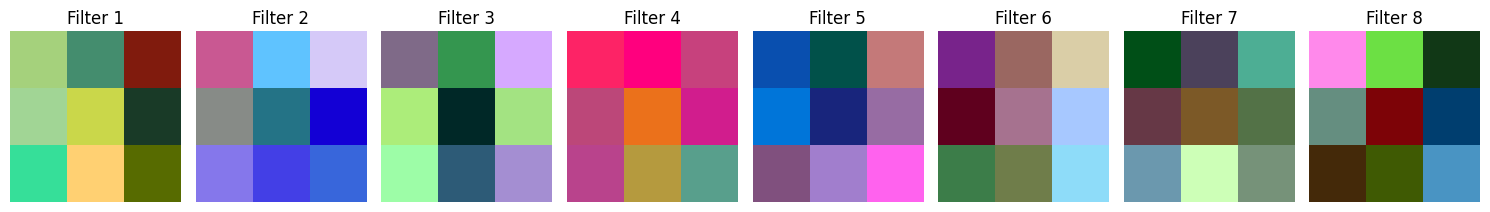

In [ ]:
import torch, torch.nn as nn, torch.optim as optim, torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt

transform = T.Compose([T.ToTensor(), T.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2); self.relu = nn.ReLU()
        self.fc1 = nn.Linear(32*8*8, 128); self.fc2 = nn.Linear(128, 10)
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32*8*8)
        return self.fc2(self.relu(self.fc1(x)))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
lossfn = nn.CrossEntropyLoss(); optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    running = 0
    for x, y in trainloader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(); out = model(x); loss = lossfn(out, y)
        loss.backward(); optimizer.step(); running += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running/len(trainloader):.4f}")

correct, total = 0, 0
with torch.no_grad():
    for x, y in testloader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item(); total += y.size(0)
print(f"Accuracy on test data: {100*correct/total:.2f}%")

filters = model.conv1.weight.data.clone().cpu()
fig, axs = plt.subplots(1, 8, figsize=(15, 4))
for i in range(8):
    f = filters[i]; f = (f - f.min())/(f.max() - f.min())
    axs[i].imshow(f.permute(1, 2, 0)); axs[i].axis('off'); axs[i].set_title(f'Filter {i+1}')
plt.tight_layout(); plt.show()
